# 1. Import libraries and load the dataset


In [1]:
import sys
from pathlib import Path

# Find the project root containing pyproject.toml
root = Path.cwd()
while root.name and not (root / 'pyproject.toml').exists():
    root = root.parent

if str(root) not in sys.path:
    sys.path.append(str(root))

import pandas as pd
from configs.config import RAW_DIR

df_oil = pd.read_csv(RAW_DIR / 'oil.csv')


In [2]:
import pandas as pd
import numpy  as np

# 2. Display basic information about the dataset

In [3]:
print("First 5 Rows of Data Frame:\n", df_oil.head(5))
print("Data Frame Shape:\n", df_oil.shape)
print("Data Frame Info:\n", df_oil.info())
print("Data Frame Statistics:\n", df_oil.describe())
    

First 5 Rows of Data Frame:
          date  dcoilwtico
0  2013-01-01         NaN
1  2013-01-02       93.14
2  2013-01-03       92.97
3  2013-01-04       93.12
4  2013-01-07       93.20
Data Frame Shape:
 (1218, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        1218 non-null   object 
 1   dcoilwtico  1175 non-null   float64
dtypes: float64(1), object(1)
memory usage: 19.2+ KB
Data Frame Info:
 None
Data Frame Statistics:
         dcoilwtico
count  1175.000000
mean     67.714366
std      25.630476
min      26.190000
25%      46.405000
50%      53.190000
75%      95.660000
max     110.620000


# 3. Missing Values Summary

In [4]:
# Calculate missing values
missing_counts = df_oil.isnull().sum()
missing_percentage = missing_counts / len(df_oil) * 100

# Create a summary DataFrame
missing_df_oil = pd.DataFrame({
    'Missing Values': missing_counts,
    'Percentage': missing_percentage
})

print("Missing Values Summary:\n", missing_df_oil)

# Filter columns with missing values
missing_df_oil = missing_df_oil[missing_df_oil['Missing Values'] > 0].sort_values(by='Missing Values', ascending=False)

Missing Values Summary:
             Missing Values  Percentage
date                     0    0.000000
dcoilwtico              43    3.530378


In [5]:
# Handle missing values for oil price (time-series data)
df_oil['date'] = pd.to_datetime(df_oil['date'])
df_oil = df_oil.sort_values('date')

# Forward fill missing oil prices
df_oil['dcoilwtico'] = df_oil['dcoilwtico'].ffill()

# Backward fill in case missing values exist at the start
df_oil['dcoilwtico'] = df_oil['dcoilwtico'].bfill()

# Recheck missing values after handling
print("Missing Values After Handling:\n", df_oil.isnull().sum())


Missing Values After Handling:
 date          0
dcoilwtico    0
dtype: int64


# 4. Oil Price Distribution

In [6]:
# Oil Price Distribution Statistics
from scipy import stats

mean_oil = df_oil['dcoilwtico'].mean()
median_oil = df_oil['dcoilwtico'].median()
std_oil = df_oil['dcoilwtico'].std()
min_oil = df_oil['dcoilwtico'].min()
max_oil = df_oil['dcoilwtico'].max()
q25_oil = df_oil['dcoilwtico'].quantile(0.25)
q75_oil = df_oil['dcoilwtico'].quantile(0.75)

# Distribution shape metrics
skewness_oil = stats.skew(df_oil['dcoilwtico'])
kurtosis_oil = stats.kurtosis(df_oil['dcoilwtico'])
cv_oil = (std_oil / mean_oil) * 100

# Mean-median gap
mean_median_gap_oil = ((mean_oil - median_oil) / median_oil) * 100

# Price range
price_range = max_oil - min_oil
price_range_pct = (price_range / min_oil) * 100

print("Oil Price Distribution Statistics:")
print("=" * 60)
print(f"Mean price: ${mean_oil:.2f}/barrel")
print(f"Median price: ${median_oil:.2f}/barrel")
print(f"Std deviation: ${std_oil:.2f}")
print(f"Min price: ${min_oil:.2f}/barrel")
print(f"Max price: ${max_oil:.2f}/barrel")
print(f"25th percentile: ${q25_oil:.2f}/barrel")
print(f"75th percentile: ${q75_oil:.2f}/barrel")

print(f"\nDistribution Characteristics:")
print("=" * 60)
print(f"Coefficient of Variation: {cv_oil:.1f}%")
print(f"Skewness: {skewness_oil:.2f}")
print(f"Kurtosis: {kurtosis_oil:.2f}")
print(f"Mean-Median gap: {mean_median_gap_oil:.1f}%")
print(f"Price range: ${price_range:.2f} ({price_range_pct:.0f}% swing)")



Oil Price Distribution Statistics:
Mean price: $67.69/barrel
Median price: $53.20/barrel
Std deviation: $25.63
Min price: $26.19/barrel
Max price: $110.62/barrel
25th percentile: $46.42/barrel
75th percentile: $95.69/barrel

Distribution Characteristics:
Coefficient of Variation: 37.9%
Skewness: 0.32
Kurtosis: -1.61
Mean-Median gap: 27.2%
Price range: $84.43 (322% swing)


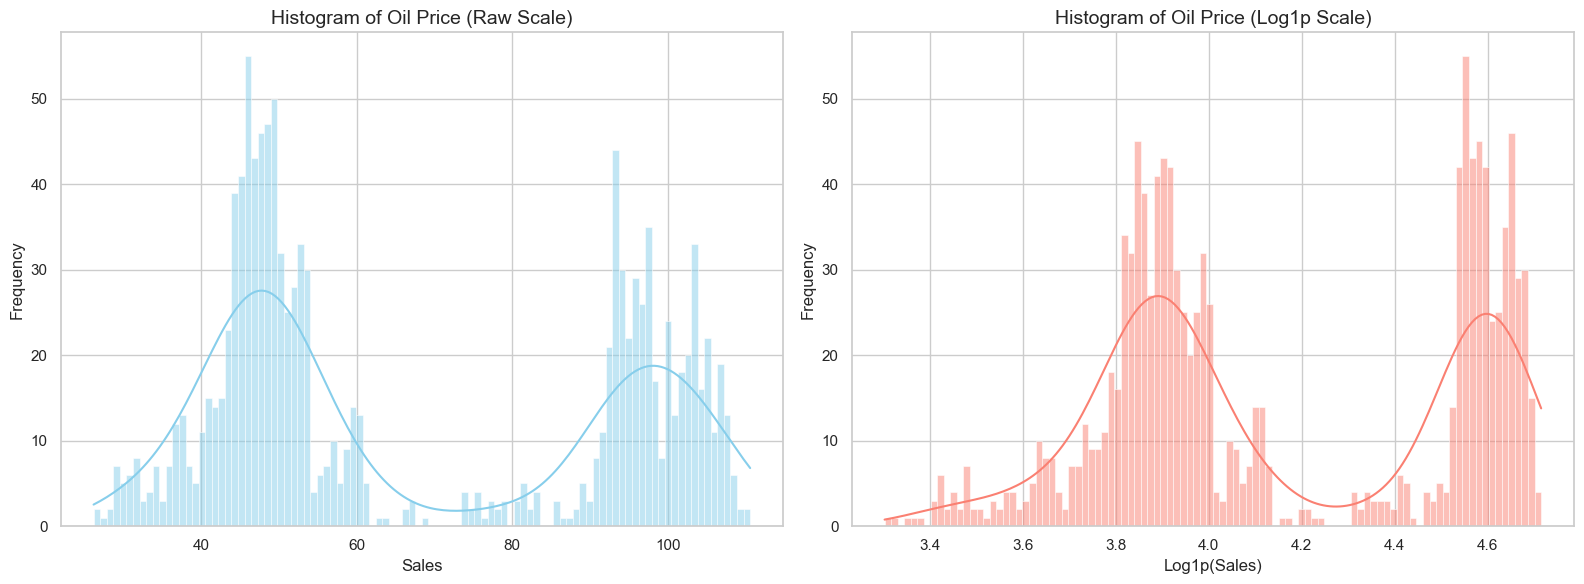

Skewness of raw sales: 0.32
Skewness of log1p sales: 0.09


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set theme and style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Histogram of raw sales (Raw scale)
sns.histplot(df_oil['dcoilwtico'], bins=100, ax=axes[0], kde=True, color='skyblue')
axes[0].set_title('Histogram of Oil Price (Raw Scale)', fontsize=14)
axes[0].set_xlabel('Sales', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)

# 2. Histogram of log-transformed sales (Log scale)
sns.histplot(np.log1p(df_oil['dcoilwtico']), bins=100, ax=axes[1], kde=True, color='salmon')
axes[1].set_title('Histogram of Oil Price (Log1p Scale)', fontsize=14)
axes[1].set_xlabel('Log1p(Sales)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)

plt.tight_layout()
plt.show()

# Calculate skewness
skew_raw = df_oil['dcoilwtico'].skew()
skew_log = np.log1p(df_oil['dcoilwtico']).skew()
print(f"Skewness of raw sales: {skew_raw:.2f}")
print(f"Skewness of log1p sales: {skew_log:.2f}")